# INFO 2950 Final Project Phase IV

## Introduction

### Research Questions
Question: Can we accurately predict the daily bike rental sharing count based on the environemntal conditions (weather, temp, hum, windspeed) and if that day is holiday or not.

In this analysis, we aim to explore correlations between daily bike rental counts and various factors, such as weather conditions and holidays. Specifically, we will investigate the relationships between temperature, humidity, wind speed, weather conditions and holiday. We will train a multivariable regression model to see if we can reliably predict the number of daily bike rentals based on these environmental and holiday conditions.

## Data Cleaning

In [16]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import duckdb
import datetime
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from scipy import stats
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [17]:
# Load dataset
data = pd.read_csv("data.csv")
data.head()

,time_period,dteday,season,yr,mnth,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,2011-01-01,1,0,1,6,0,1,0.24,0.2879,0.81,0.0,16
1,1,2011-01-01,1,0,1,6,0,1,0.22,0.2727,0.80,0.0,40
2,1,2011-01-01,1,0,1,6,0,1,0.22,0.2727,0.80,0.0,32
3,1,2011-01-01,1,0,1,6,0,1,0.24,0.2879,0.75,0.0,13
4,1,2011-01-01,1,0,1,6,0,1,0.24,0.2879,0.75,0.0,1


## Data Description

### What are the observations (rows) and the attributes (columns)?

The observations (rows) represent a particular time period each day from 2011 and 2012 in the Capital bikeshare system of bike-sharing data, where the weather, seasonal information, and the number of bike rentals is recorded.

The attributes (columns) includes:
- time_period: 
    - 1: Hour 0-5 (dawn)
    - 2: Hour 6-11 (morning)
    - 3: Hour 12-17 (afternoon)
    - 4: Hour: 18-23 (night)	
- dteday: date
- season: 
    - 1: Spring
    - 2: Summer
    - 3: Fall
    - 4: Winter
- mnth: month ( 1 to 12)
- workingday: if day is neither weekend nor holiday is 1, otherwise is 0.
- weathersit_score:
    - 1: Clear, Few clouds, Partly cloudy, Partly cloudy
    - 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
    - 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
    - 4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog
- temp: Normalized temperature in Celsius. The values are divided to 41 (max)	
- atemp: Normalized feeling temperature in Celsius. The values are divided to 50 (max)
- hum: Normalized humidity. The values are divided to 100 (max)	
- windspeed: Normalized wind speed. The values are divided to 67 (max)	
- cnt: count of total rental bikes including both casual and registered


### Why was this dataset created?

Hadi Fanaee-T and Joao Gama created this dataset to study how the number of bike rentals are influenced by various factors, including time and environmental conditions. It was used to develop models to predict the demand of bike-sharing, which is useful for planning and improving current bike-sharing systems.

### Who funded the creation of the dataset?

The creation of the bike-sharing dataset was funded by these sources:
1. European Regional Development Fund through the COMPETE Program.
2. Portuguese Funds through the Portuguese Foundation for Science and Technology (FCT) within the project FCOMP — 01-0124-FEDER-022701.
3. European Commission through the project MAESTRA (Grant Number ICT-2013-612944).


### What processes might have influenced what data was observed and recorded and what was not?


Since the data is related to a 2-year usage log of Capital Bike Sharing (CBS) at Washington, D.C., USA , the types of data observed and recorded are mostly for operational purposes. For example, the number of bikes rented per day was recorded for tracking and usage. CBS also needed to consider user privacy, so information such as user description and live bicycle location were not recorded.

### What preprocessing was done, and how did the data come to be in the form that you are using?


The authors normalized values for temperature, humidity, and wind speed to help the model reduce variance between different environmental variables. Additionally, my team and I deleted some attributes (columns) that we feel would be correlated with other attributes. We also transformed the observations (rows) from every hour to every time period (every six hours) because our results would be more interpretable to more readers. When transforming the hour data, we also transformed the weather data to be averaged out between the aggregated hours. 

### If people are involved, were they aware of the data collection and if so, what purpose did they expect the data to be used for?


The bikeshare users were probably not explicitly aware, but had a slight idea, that certain data from them was being collected. We believe these riders agreed to the general collection of data when using CBS by a terms and conditions agreement, which people usually skip through and agree. Generally, users would likely expect the data to be anonymized and used for operational improvements purposes. 


### Where can your raw source data be found, if applicable? Provide a link to the raw data (hosted on Github, in a Cornell Google Drive or Cornell Box)


Not applicable. We found our dataset on UCI Machine Learning Repository. 


## Preregistration Statements

### Statement 1
Hypothesis 1: Temperature and humidity jointly influence daily bike rental counts, with temperature having a positive effect and humidity moderating the relationship.
Analysis: We will run a multiple linear regression where the input variables are temperature and humidity, and the output variable is the daily bike rental count. Specifically, we will test the following:
1. Whether the coefficient for temperature (B_temperature​) is significantly greater than 0, indicating that higher temperatures are associated with an increase in bike rentals.
2. Whether the coefficient for humidity (B_humidity) is significantly different from 0, assessing its impact on bike rentals.
Whether an interaction term between temperature and humidity (B_temperature×humidity​) is significant, exploring whether humidity moderates the effect of temperature on bike rentals.
3. This approach will allow us to determine not only the independent effects of temperature and humidity but also how these factors interact to influence daily bike rental counts.unts.





### Statement 2
Hypothesis 2: Workingday status affects bike rental counts, with fewer rentals expected during non-workdays. 

Analysis: We will run a linear regression with workingday status as a dummy variable (1 for working day, 0 for non-working day) and daily bike rental count as the output variable. We will test whether the coefficient for the workingday dummy (B_workingday) is less than 0, indicating that fewer bikes are rented on working days.

## Data Analysis

### Data Exploratory Analysis

We first look at the correlation and covariance between total bike rental count and the variables related to weather conditions ('weathersit_score', 'temp', 'atemp', 'hum', 'windspeed', 'cnt'). The correlation and covariance can provide a rough estimate of the relationships between the weather related variables and the total bike rental count.

In [18]:
# the corrleation between the weather variables and the total count
variable = ['weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt']
data[variable].corr()

,weathersit,temp,atemp,hum,windspeed,cnt
weathersit,1.000000,-0.102640,-0.105563,0.418130,0.026226,-0.142426
temp,-0.102640,1.000000,0.987672,-0.069881,-0.023125,0.404772
atemp,-0.105563,0.987672,1.000000,-0.051918,-0.062336,0.400929
hum,0.418130,-0.069881,-0.051918,1.000000,-0.290105,-0.322911
windspeed,0.026226,-0.023125,-0.062336,-0.290105,1.000000,0.093234
cnt,-0.142426,0.404772,0.400929,-0.322911,0.093234,1.000000


In [19]:
# the covariance matrix between the weather variables and the total count
pd.set_option('display.float_format', '{:.2f}'.format)
data[variable].cov()

,weathersit,temp,atemp,hum,windspeed,cnt
weathersit,0.41,-0.01,-0.01,0.05,0.00,-16.52
temp,-0.01,0.04,0.03,-0.00,-0.00,14.14
atemp,-0.01,0.03,0.03,-0.00,-0.00,12.50
hum,0.05,-0.00,-0.00,0.04,-0.01,-11.30
windspeed,0.00,-0.00,-0.00,-0.01,0.01,2.07
cnt,-16.52,14.14,12.50,-11.30,2.07,32901.46


Observations:
1. Warmer temperatures (both temp and atemp) positively influence bike rentals, while higher humidity negatively influence bike rentals.
2. Windspeed seems to have little impact on bike rentals.

Then we want to explore the relationship between “weathersit_score” and “cnt”.
We would like to know if different weather situation scores are related to change in the total bike rental count. Below, we calculated the mean bike rental count for each weather situation score and plot a boxplot. According to the boxplot, it seems that the more extreme the weather is, the total number of bike rentals will decrease.

In [ ]:
# find the average of total bike rental count for each weather situation condition
weather_cnt_analyze = duckdb.sql("SELECT weathersit_score, AVG(cnt) AS cnt_avg\
                              FROM data \
                              GROUP BY weathersit_score \
                              ORDER BY weathersit_score").df()
weather_cnt_analyze

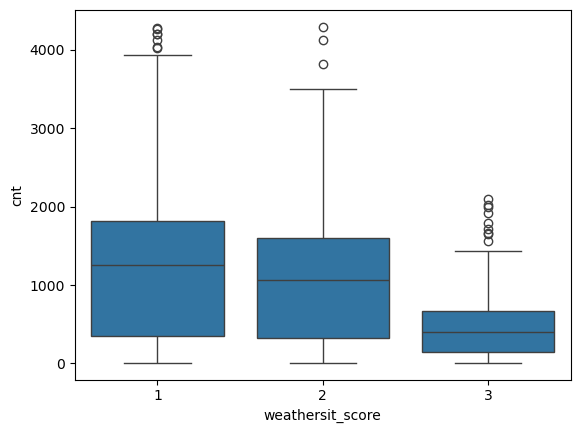

In [ ]:
# boxplot of weathersit_score and total rental count
sns.boxplot(data, x='weathersit', y='cnt');

Observations:
1. As the weather becomes worse (higher weathersit_score), bike rentals' average and median decrease, and there are fewer outliers.
2. Favorable weather conditions (lower weathersit_score) correspond with the highest number of bike rentals, with a wider range of values, suggesting that people are more likely to rent bikes on such days.

We realize that although the weather situation has scores 1, 2, 3, 4, the boxplot only shows the weather situation for 1, 2, and 3 but there is no weather condition 4. Weather situation 4 stands for “Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog.” By looking back at the original dataset, we found that there were three cases of weather situation 4, but at the end was averaged out during the data cleaning process.

In [ ]:
data[data['weathersit'] == 4]

,dteday,season,mnth,hr,workingday,weathersit,temp,atemp,hum,windspeed,cnt
585,2011-01-26,1,1,16,1,4,0.22,0.20,0.93,0.33,36
8854,2012-01-09,1,1,18,1,4,0.20,0.23,0.86,0.09,164
9123,2012-01-21,1,1,1,0,4,0.14,0.14,0.86,0.19,23


We also want to explore the total bike rental count change over time. Below is a line plot of total rental count based on date.
According to the line plot, the total bike rental count increases from January to May, and decreases from September to December. People tend to rent a bike more in May to September.

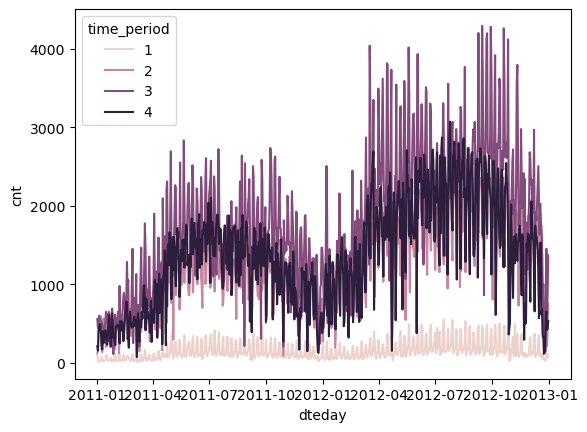

In [ ]:
# plot the change of total rental count over time (day)
sns.lineplot(data, x='dteday', y='cnt', hue="time_period");

The graph above is too hard to read, but there is indeed some pattern occured over this time period. We decided to plot based on months.

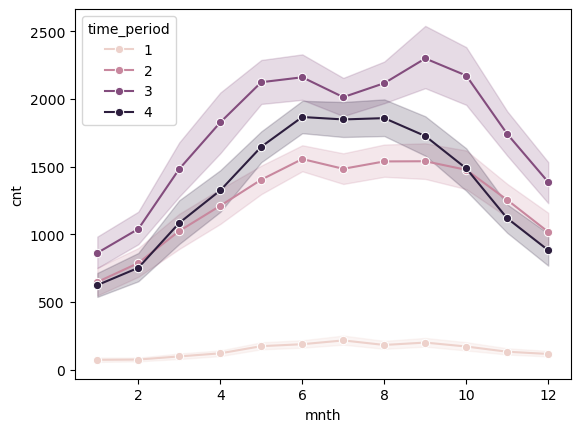

In [ ]:
# plot the change of total rental count over time (months)
sns.lineplot(data, x='mnth', y='cnt', hue="time_period", marker='o');

Observations:
1. This graph shows the highest usage of bike rentals are during summer and the lowest during winter. 
2. Time period 3 (afternoon, hour 12-17) consistently sees the most rentals, while time period 1 (dawn, hour 0-5) has the least rentals. 

We want to explore how the change in time of the day can impact the total bike rental count. Below we calculated the average bike rental count for each time period of the day and produced a boxplot of total bike rental count based on time period.
According to the boxplot, people are most likely to rent a bike during afternoons and very unlikely to rent a bike during dawn time. 

In [ ]:
# find the mean of the total rental count for each time period
data_cnt_analyze = duckdb.sql("SELECT time_period, AVG(cnt) AS cnt_avg\
                              FROM data \
                              GROUP BY time_period \
                              ORDER BY time_period").df()
data_cnt_analyze

,time_period,cnt_avg
0,1,146.71
1,2,1248.03
2,3,1770.88
3,4,1354.55


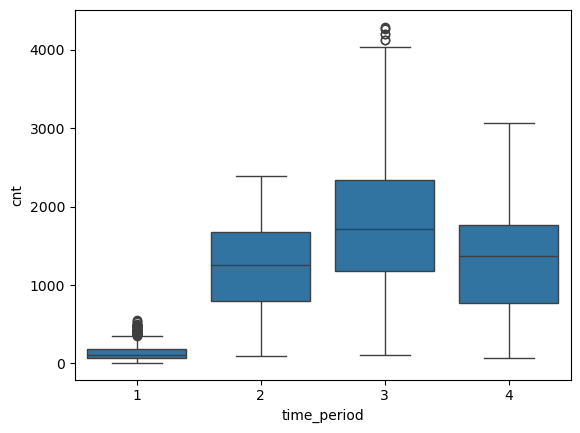

In [ ]:
# boxplot of time period and total rental count
sns.boxplot(data, x='time_period', y='cnt');

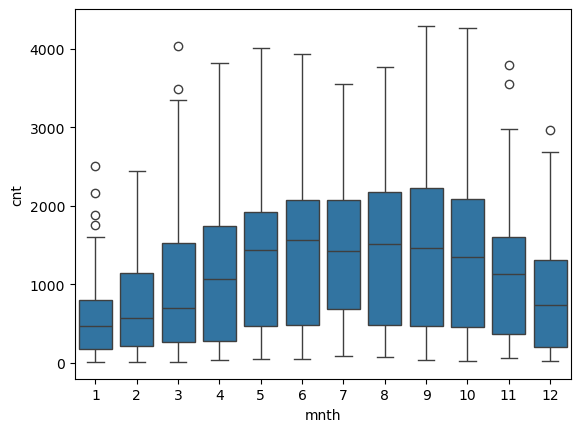

In [ ]:
# boxplot of months and total rental count
sns.boxplot(data, x='mnth', y='cnt');

Observations:
1. Time period 3 (afternoon, hour 12-17) corresponds with the highest bike rental counts, while Time period 1 (dawn, hour 0-5)corresponds with the fewest.
2. Summer (June to August) corresponds with the most bike rentals, and winter (December and January) corresponds with the fewest.

### Statement 1 Analysis
Our statement 1 includes the following variables: counts of bike rented, temperature, humidity.

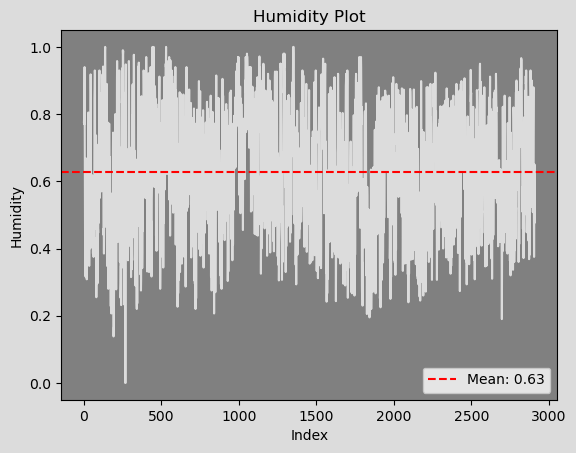

In [ ]:
### Exploratory Analyse to Statement 1
## Humidity
plt.style.use('default')


plt.plot(data['hum'], color= '#AC72B0')


mean_hum = data['hum'].mean()

plt.axhline(y=mean_hum, color='r', linestyle='--', label=f'Mean: {mean_hum:.2f}')

plt.title("Humidity Plot")
plt.xlabel("Index")
plt.ylabel("Humidity")
plt.legend(loc = 'lower right')
plt.show()


From the exploratory analysis of the humidity variable, we observe that the majority of the humidity values throughout the year range between 0.2 and 1.0. The average humidity is approximately 0.63, as indicated by the red dashed line in the plot.

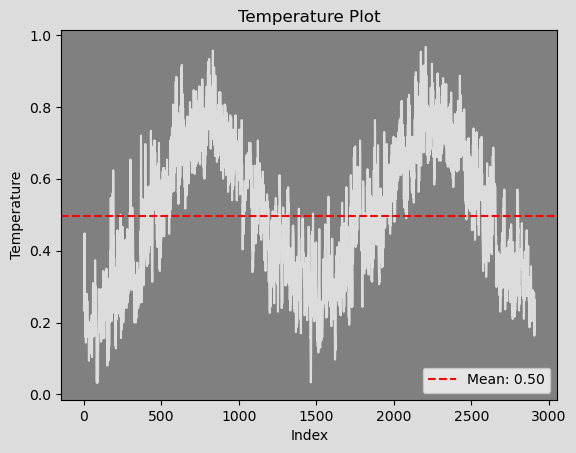

In [ ]:
### Exploratory Analyse to Statement 1
## Temperature
plt.style.use('default')


plt.plot(data['temp'], color = '#AC72B0')
mean_temp = data['temp'].mean()

plt.axhline(y=mean_temp, color='r', linestyle='--', label=f'Mean: {mean_temp:.2f}')

plt.title("Temperature Plot")
plt.xlabel("Index")
plt.ylabel("Temperature")
plt.legend(loc = 'lower right')
plt.show()

From the exploratory analysis of the temperature variable, it can be observed that the values exhibit a cyclical pattern, likely reflecting seasonal variations. The temperature values range between 0.0 and 1.0, with an average of 0.50, as indicated by the red dashed line. This suggests a relatively balanced distribution of temperature over the observed period, with peaks and troughs that highlight periodic changes.

In [ ]:
### Regression Analyse to Statement 1
X = data[['hum', 'temp']]
X = sm.add_constant(X)
y = data['cnt']

model = sm.OLS(y, X).fit()


print("Regression Coefficients:")
print(f"Beta_0 (Intercept): {model.params['const']:.4f}")
print(f"Beta_1 (Humidity - hum): {model.params['hum']:.4f}")
print(f"Beta_2 (Temperature - temp): {model.params['temp']:.4f}")

print("\nFull Regression Summary:")
print(model.summary())

The regression results show that humidity negatively affects daily bike rental counts(β1= -1647.72, p < 0.5), while temperaturety has positive effect (β2 = 2153.8927, p < 0.05). The model explains 36.2% of the variation in bike rentals R^2 = 0.3.

## Evaluation of Significance

### Evaluation of Statistical Significance for Statement 1

Based on the regression analysis results, here is an evaluation of statistical significance, along with clear interpretations and conclusions derived from the findings.ance

In this analysis, we examined the effects of humidity (`hum`) and temperature (`temp`) on bike rental counts (`cnt`). The regression coefficients and associated p-values offer valuable insights into these relationships.

- **Intercept (β0)**: 1096.9971, with a p-value of 0.000. This value represents the baseline bike rental count when humidity and temperature are both zero. Although zero values for humidity and temperature are unlikely in practice, this intercept provides a reference point for the model.

- **Humidity (β1)**: -1647.7155, with a p-value of 0.000. The negative coefficient indicates that an increase in humidity significantly decreases bike rental counts. The 95% confidence interval ([-1785.131, -1510.300]) suggests that this negative effect is statistically significant. The low p-value (<0.05) further confirms the high statistical significance of this relationship.

- **Tempebeta (β2)**: 2153.8927, with a p-value of 0.000. The positive coefficient suggests that an increase in temperature significantly increases bike rental counts. The 95% confidence interval ([2023.383, 2284.402]) confirms that this positive impact is statistically significant, with the p-value also well below 0.05, emphasizing a strong positive relationship between temperature and rental counts.

---

### Interpretation of the Model

- **R-squared**: The R-squared value of 0.362 indicates that humidity and temperature together explain 36.2% of the variation in bike rental counts. Although this is a moderate level of explanatory power, it underscores the importance of temperature and humidity as influential factors in rental demand.

- **Model Significance**: The F-statistic is 823.8, with a p-value less than 0.001, indicating that the model is statistically significant as a whole. This suggests that the combined effect of temperature and humidity on bike rental counts is lying clear, actionable insights.

## Conclusions

### Conclusion and Insights For Statement 1

Overall, temperature and humidity have opposite and significant effects on bike rental counts. Higher temperatures substantially increase rental demand, while higher humidity significantly decreases it. These findings lead to several practical conclusions:

- Bike rental demand is likely higher in warm, dry weather conditions.
- Monitoring weather conditions can support better planning and management of bike rental services to meet higher demand on favorable days.

This report presents a coherent analysis of the significance of temperature and humidity on bike rental counts, providing a data-driven basis for decision-making. The results highlight the different impacts of these factors, offering clear, actionable insights.

### Statement 2 Analysis
How does Workingday Status affect bike rental counts?
- Would there be more bike being rented on working days compared to non-working days?

In [21]:
X = data['workingday']
y = data['cnt']

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     15.95
Date:                Thu, 21 Nov 2024   Prob (F-statistic):           6.52e-05
Time:                        22:37:12   Log-Likelihood:            -1.1503e+05
No. Observations:               17379   AIC:                         2.301e+05
Df Residuals:                   17377   BIC:                         2.301e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        181.4053      2.442     74.296      0.0

The F-statistic is 15.95 with a very small p-value of 6.52e-05, meaning that the overall model is significant. The adjusted R-squared value of the model is 0.001, which means only 0.1% of the data can be explained using this model, which means that workday may not be significantly contributing to the prediction of the bike rental counts.

In [22]:
# T test
# compare the mean of non-workday to workdays
workday = data[data['workingday'] == 1].cnt
non_workday = data[data['workingday'] == 0].cnt
tstatH, pvalH = stats.ttest_ind(a=workday, b=non_workday, equal_var=False)[:]
print(f'The tstat is {round(tstatH, 3)} and the pval is {pvalH}.')

The tstat is 4.095 and the pval is 4.249478377549554e-05.


In the cell above, we conducted a t-test to compare the average daily bike rental count for working days and non-working days. We received a t-statistics of 4.095 and a p-value of 4.250e-05. The p-value is significantly less than the alpha value 0.05. Therefore, there is enough evidence suggesting that working day is associated with a higher number of daily bike rental counts.

<Axes: xlabel='workingday', ylabel='cnt'>

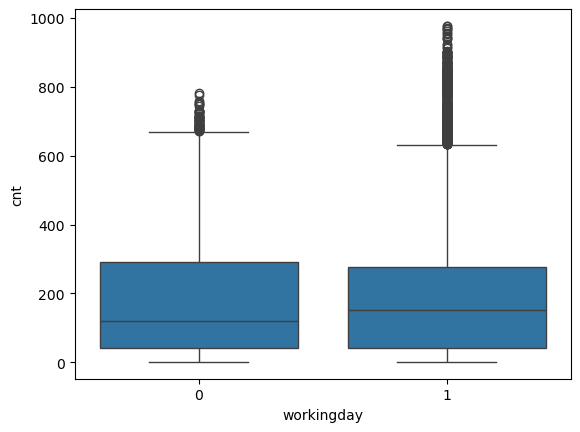

In [23]:
# create a graph comparing workday and non-workday
sns.boxplot(data=data, x='workingday', y='cnt')

As shown by the boxplot above, the total bike rental counts seem to be lower on non-working days compared to working days. This plot matches with our conclusion from the previous regression analysis that working day is associated with a higher number of daily bike rental counts.

#### Question: On which weekday will there be more bikes being rented?

In [24]:
# convert day of the week into dummy variables
weekday_dummy = pd.get_dummies(data['weekday'])
weekday_dummy = weekday_dummy.rename(columns={0:'Sun', 1:'Mon', 2:'Tue', 3:'Wed', 4:'Thu', 5:'Fri', 6:'Sat'})

In [25]:
# regression
y = data['cnt']
X = weekday_dummy.astype(int)
X = sm.add_constant(X)

model_day = sm.OLS(y, X).fit()
model_day.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     2.987
Date:                Thu, 21 Nov 2024   Prob (F-statistic):            0.00392
Time:                        22:39:29   Log-Likelihood:            -1.1503e+05
No. Observations:               17379   AIC:                         2.301e+05
Df Residuals:                   17371   BIC:                         2.301e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.934e+13   1.53e+14      0.127      0.899    -2.8e+14    3.19e+14
Sun        -1.934e+13   1.53e+14     -0.127      0.899   -3.19e+14     2.8e+14
Mon        -1.934e+13   1.53e+14     -0.127      0.899   -3.19e+14     2.8e+14
Tue        -1.934e+13   1.53e+14     -0.127      0.899   -3.19e+14     2.8e+14
Wed        -1.934e+13   1.53e+14     -0.127      0.899   -3.19e+14     2.8e+14
Thu        -1.934e+13   1.53e+14     -0.127      0.899   -3.19e+14     2.8e+14
Fri        -1.934e+13   1.53e+14     -0.127      0.899   -3.19e+14     2.8e+14
Sat        -1.934e+13   1.53e+14     -0.127      0.899   -3.19e+14     2.8e+14
==============================================================================
Omnibus:                     3443.705   Durbin-Watson:                   0.313
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             6126.129
Skew:                           1.275   Prob(JB):                         0.00
Kurtosis:                       4.401   Cond. No.                     3.36e+14
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 1.76e-25. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

The F-statistic is 2.987 with a small p-value of 0.00392, meaning that the overall model is significant. The adjusted R-squared value of the model is 0.001, which means only 0.1% of the data can be explained using this model, which means that weekday may not be significantly contributing to the prediction of the bike rental counts.

The p-values for each dummy variables, surprisingly are all the same (0.899), which are much larger than 0.05. Therefore, we fail to reject the null hypothesis and the difference in weekdays does not affect the daily bike rental counts.

<Axes: xlabel='weekday', ylabel='cnt'>

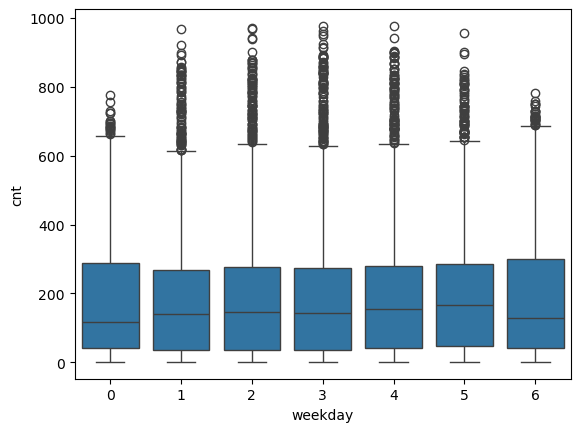

In [26]:
# plot a box graph of weekday vs daily bike rental counts
sns.boxplot(data=data, x='weekday', y='cnt')

From the boxplot, we can tell that Saturday and Sunday have the lowest amount of daily bike rental counts. There aren't any significance difference in the mean bike rental counts during the weekday, but Friday has a little more bike rentals. However, none of the differences are big enough and that may be the reason why none of the weekdays are significant in the above regression analysis.

We decided to conduct an ANOVA test to explore if the difference in each day of the week are associated with the difference in the bike rental counts of that day.

In [28]:
# ANOVA TEST for weekday
model = ols('cnt ~ C(weekday)', data = data).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
anova_table

,sum_sq,df,F,PR(>F)
C(weekday),687929.44,6.00,3.49,0.00
Residual,571073661.63,17372.00,NaN,NaN


This ANOVA model has a f-statistic of 3.48779 and a p-value of 0.0019, indicating there is significant difference between the means of each group. Therefore, the change in different days of the week does lead to a significant difference in the bike rental counts for each day.

In [29]:
# Conduct a Tukey Test to check for pair-wise comparisons
tukey = pairwise_tukeyhsd(endog=data['cnt'],
                          groups=data['weekday'],
                          alpha=0.05)
tukey.summary()

c:\Users\xinya\anaconda3\envs\info2950\Lib\site-packages\scipy\integrate\_quadpack_py.py:1260: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,


group1,group2,meandiff,p-adj,lower,upper,reject
0,1,6.2758,0.8861,-8.8745,21.4262,False
0,2,13.7701,0.1052,-1.4206,28.9607,False
0,3,13.6617,0.1092,-1.4948,28.8182,False
0,4,18.9678,0.0042,3.8052,34.1305,True
0,5,18.6671,0.0052,3.529,33.8052,True
0,6,12.741,0.1636,-2.3593,27.8413,False
1,2,7.4942,0.7736,-7.7313,22.7197,False
1,3,7.3858,0.7836,-7.8056,22.5773,False
1,4,12.692,0.1732,-2.5056,27.8896,False
1,5,12.3913,0.195,-2.7818,27.5643,False


From this summary, we can tell that the bike rental counts on Sunday is significantly different than the bike rental counts on Thursdays and Fridays. Therefore, Saturdays probably have a very different bike rental counts in the week.

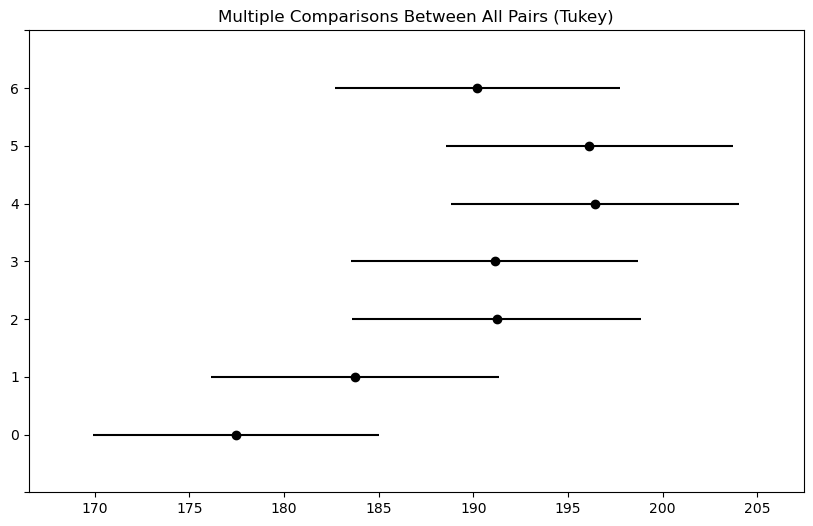

In [30]:
tukey.plot_simultaneous();

The 95% confidence interval plot reinforces the results visually: the confidence interval of Friday and Thursday do no overlap with the confidence interval of Sunday.

#### Question: Does time of the day effect the number of bike rental counts?

In [31]:
# convert time of the day into dummy variables
time_dummy = pd.get_dummies(data['time_period'])
time_dummy = time_dummy.rename(columns={1:'dawn', 2:'morning', 3:'afternoon', 4:'night'})

In [32]:
# regression
y = data['cnt']
X = time_dummy.astype(int)
X = sm.add_constant(X)
model_day = sm.OLS(y, X).fit()
model_day.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.301
Model:                            OLS   Adj. R-squared:                  0.301
Method:                 Least Squares   F-statistic:                     1872.
Date:                Thu, 21 Nov 2024   Prob (F-statistic):               0.00
Time:                        22:53:29   Log-Likelihood:            -1.1193e+05
No. Observations:               17379   AIC:                         2.239e+05
Df Residuals:                   17374   BIC:                         2.239e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -3.91e+13   3.91e+14     -0.100      0.920   -8.05e+14    7.27e+14
dawn         3.91e+13   3.91e+14      0.100      0.920   -7.27e+14    8.05e+14
morning      3.91e+13   3.91e+14      0.100      0.920   -7.27e+14    8.05e+14
afternoon    3.91e+13   3.91e+14      0.100      0.920   -7.27e+14    8.05e+14
night        3.91e+13   3.91e+14      0.100      0.920   -7.27e+14    8.05e+14
==============================================================================
Omnibus:                     4116.931   Durbin-Watson:                   0.519
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             9652.220
Skew:                           1.331   Prob(JB):                         0.00
Kurtosis:                       5.499   Cond. No.                     8.50e+14
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 3.01e-26. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

The F-statistic is 1872 with a very small p-value of 0.00, meaning that the overall model is significant. The adjusted R-squared value of the model is 0.301, which means about 30.1% of the data can be explained using this model.

The p-values for each dummy variables are 0.920, which is significantly higher than the threshold of 0.05. This means we fail to reject the null hypothesis and time of the day does not have an effect on the daily bike rental counts.

## Limitations

## Acknowledgements and Bibliography